# Brent Oil Price — Time Series Properties

Investigating trend, stationarity, and volatility in the raw price series and
log returns, to inform the change point modeling approach in Task 2.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('../data/BrentOilPrices.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)

print(df.shape)
df.head()

(9011, 1)


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


## 1. Trend Analysis

Plot the raw price series to visually inspect long-run direction, structural
shifts, and periods of high volatility.

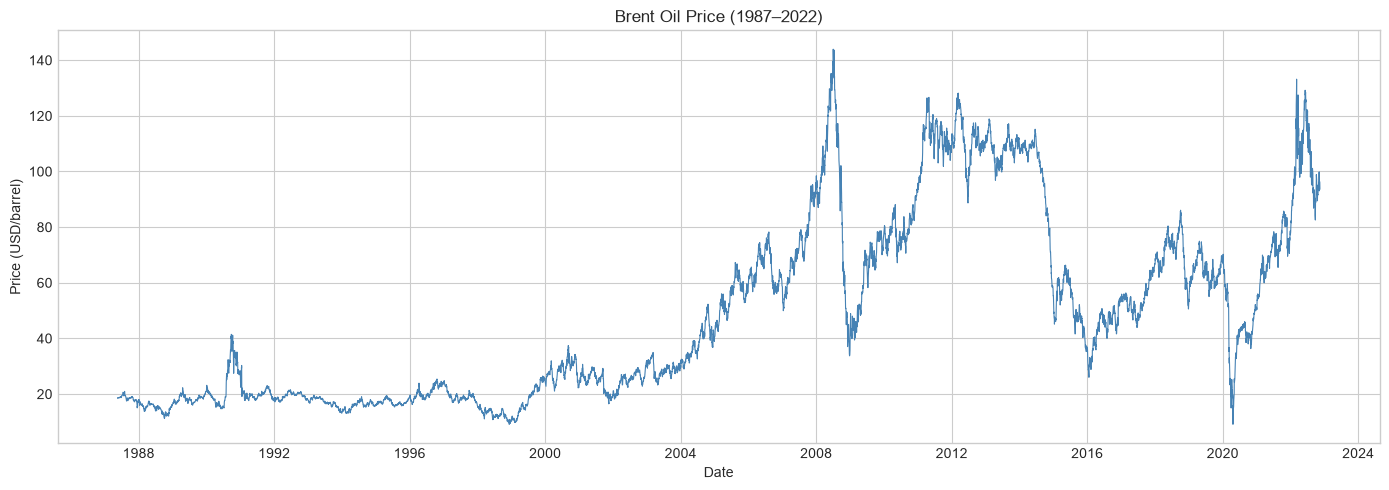

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Price'], linewidth=0.8, color='steelblue')
ax.set_title('Brent Oil Price (1987–2022)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
plt.tight_layout()
plt.show()

The raw series shows a clear **non-stationary, trending** pattern: long
multi-year upward and downward swings (e.g., the 2003–2008 rally, the
2008 crash, the 2014–2016 collapse, the 2020 COVID crash) rather than
fluctuation around a fixed mean. This visually confirms the price level
is not suitable for direct Gaussian change point modeling without
transformation — the mean itself drifts continuously, which would make
every window look like a "change."

## 2. Stationarity Testing

Test the raw price series and log returns using the Augmented Dickey-Fuller
(ADF) and KPSS tests.

- ADF null hypothesis: series has a unit root (is non-stationary).
- KPSS null hypothesis: series is stationary (opposite direction — used together
  to cross-check).

In [7]:
def run_stationarity_tests(series, name):
    series = series.dropna()
    adf_result = adfuller(series)
    kpss_result = kpss(series, regression='c', nlags='auto')

    print(f"--- {name} ---")
    print(f"ADF Statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}")
    print("  -> Stationary" if adf_result[1] < 0.05 else "  -> Non-stationary (fail to reject unit root)")
    print(f"KPSS Statistic: {kpss_result[0]:.4f}, p-value: {kpss_result[1]:.4f}")
    print("  -> Non-stationary" if kpss_result[1] < 0.05 else "  -> Stationary")
    print()

run_stationarity_tests(df['Price'], 'Raw Price')

df['log_price'] = np.log(df['Price'])
df['log_return'] = df['log_price'].diff()

run_stationarity_tests(df['log_return'], 'Log Returns')

D:\Temp\ipykernel_20332\2124279868.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


--- Raw Price ---
ADF Statistic: -1.9939, p-value: 0.2893
  -> Non-stationary (fail to reject unit root)
KPSS Statistic: 9.5588, p-value: 0.0100
  -> Non-stationary

--- Log Returns ---
ADF Statistic: -16.4271, p-value: 0.0000
  -> Stationary
KPSS Statistic: 0.0343, p-value: 0.1000
  -> Stationary



D:\Temp\ipykernel_20332\2124279868.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


**Expected result**: the raw price series fails the stationarity check (ADF
p-value high, KPSS p-value low) — consistent with the visual trend above.
Log returns, `log(P_t) - log(P_{t-1})`, are expected to pass both tests as
stationary. This is the standard transformation for financial price series:
it removes the trend and stabilizes the series around a roughly constant
mean, at the cost of no longer being in price units directly (it represents
the daily percentage change, approximately).

**Modeling implication**: for change point detection, we apply the model to
log returns (or a rolling volatility measure derived from them) when
looking for shifts in *volatility regime*, and can apply it directly to raw
price (or log price) when looking for shifts in the *price level/trend*
itself — these answer different questions, so both are worth modeling
depending on the stakeholder question being asked.

## 3. Volatility Patterns

Plot log returns directly, and a rolling standard deviation, to check for
volatility clustering (periods of calm followed by periods of turbulence).

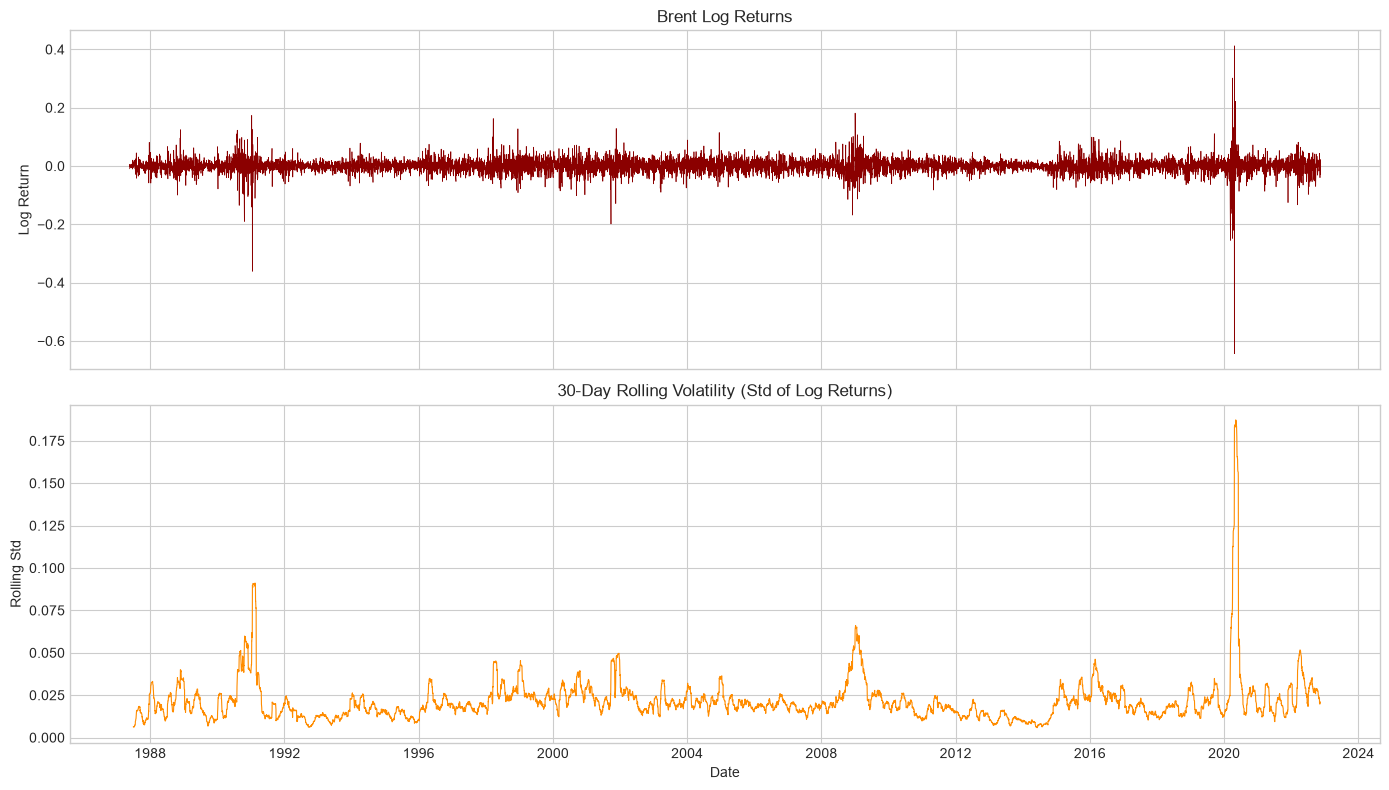

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['log_return'], linewidth=0.5, color='darkred')
axes[0].set_title('Brent Log Returns')
axes[0].set_ylabel('Log Return')

rolling_vol = df['log_return'].rolling(window=30).std()
axes[1].plot(df.index, rolling_vol, linewidth=0.8, color='darkorange')
axes[1].set_title('30-Day Rolling Volatility (Std of Log Returns)')
axes[1].set_ylabel('Rolling Std')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

Log returns show classic **volatility clustering**: large swings visibly
bunch together around known crisis periods (2008–09, 2014–16, 2020) rather
than being spread evenly across the whole history. The rolling volatility
plot makes these regimes explicit — volatility itself appears to jump
between calmer and more turbulent states.

**Modeling implication**: this motivates extending the basic mean-shift
change point model (Task 2) to also consider a **variance shift** at `tau`
(or a variance-only change point model), since some of the most important
regime changes in oil markets are volatility shifts, not just mean-level
shifts. It also justifies treating each detected segment as only
locally/regime-wise stationary, not stationary over the full 35-year history.

## Summary of Findings
| Property | Raw Price | Log Returns |
|---|---|---|
| Trend | Strong, non-stationary | None (mean ≈ 0) |
| Stationarity | Non-stationary | Stationary |
| Volatility | N/A (trend dominates) | Clustered, regime-dependent |

These findings directly justify: (1) modeling log returns rather than raw
price when testing for mean-shift change points in the "typical daily
move," (2) allowing for a variance parameter that can also shift at `tau`,
and (3) treating the full history as a sequence of regimes rather than one
globally stationary process.